# 📊 Unemployment Analysis with Python

## Introduction

Unemployment is one of the most important economic indicators of a country. The Covid-19 pandemic had a significant impact on employment opportunities worldwide.

In this project, we analyze unemployment data in India using Python. The objective is to identify unemployment trends, study the impact of Covid-19, compare unemployment across regions, and generate meaningful insights through data visualization.

## Import Libraries

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

## Load Dataset

In [9]:
df = pd.read_csv("unemployement.csv")

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (768, 7)


,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


## Dataset Information

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    object 
 1    Date                                     740 non-null    object 
 2    Frequency                                740 non-null    object 
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    object 
dtypes: float64(3), object(4)
memory usage: 42.1+ KB


In [11]:
df.describe()

,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
count,740.000000,7.400000e+02,740.000000
mean,11.787946,7.204460e+06,42.630122
std,10.721298,8.087988e+06,8.111094
min,0.000000,4.942000e+04,13.330000
25%,4.657500,1.190404e+06,38.062500
50%,8.350000,4.744178e+06,41.160000
75%,15.887500,1.127549e+07,45.505000
max,76.740000,4.577751e+07,72.570000


In [12]:
df.columns

Index(['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)',
       ' Estimated Employed', ' Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='object')

## Data Cleaning

In [15]:
# Remove extra spaces from column names
df.columns = df.columns.str.strip()

# Missing values
print(df.isnull().sum())

# Remove missing values
df = df.dropna()

print("Shape after cleaning:", df.shape)

Region                                     28
Date                                       28
Frequency                                  28
Estimated Unemployment Rate (%)            28
Estimated Employed                         28
Estimated Labour Participation Rate (%)    28
Area                                       28
dtype: int64
Shape after cleaning: (740, 7)


## Convert Date Column

In [16]:
df['Date'] = pd.to_datetime(df['Date'])

df.head()

C:\Users\shukl\AppData\Local\Temp\ipykernel_8924\3300519020.py:1: UserWarning: Parsing dates in  %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Date'] = pd.to_datetime(df['Date'])
C:\Users\shukl\AppData\Local\Temp\ipykernel_8924\3300519020.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Date'] = pd.to_datetime(df['Date'])


,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,2019-05-31,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,2019-06-30,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,2019-07-31,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,2019-08-31,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,2019-09-30,Monthly,5.17,12256762.0,44.68,Rural


# Exploratory Data Analysis (EDA)

## Unemployment Rate Distribution

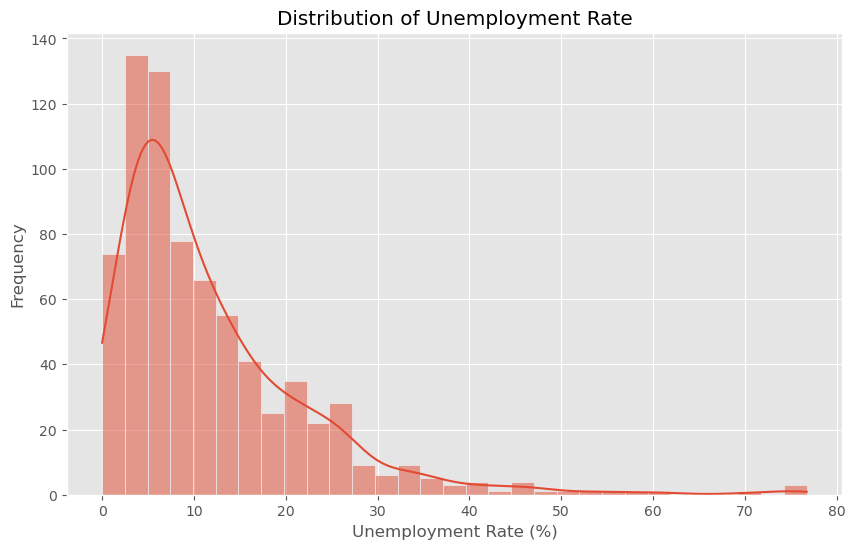

In [17]:
plt.figure(figsize=(10,6))
sns.histplot(df['Estimated Unemployment Rate (%)'], kde=True)

plt.title("Distribution of Unemployment Rate")
plt.xlabel("Unemployment Rate (%)")
plt.ylabel("Frequency")
plt.show()

## Average Unemployment Rate

In [18]:
avg_unemployment = df['Estimated Unemployment Rate (%)'].mean()

print("Average Unemployment Rate:", round(avg_unemployment, 2), "%")

Average Unemployment Rate: 11.79 %


## Unemployment Trend Over Time

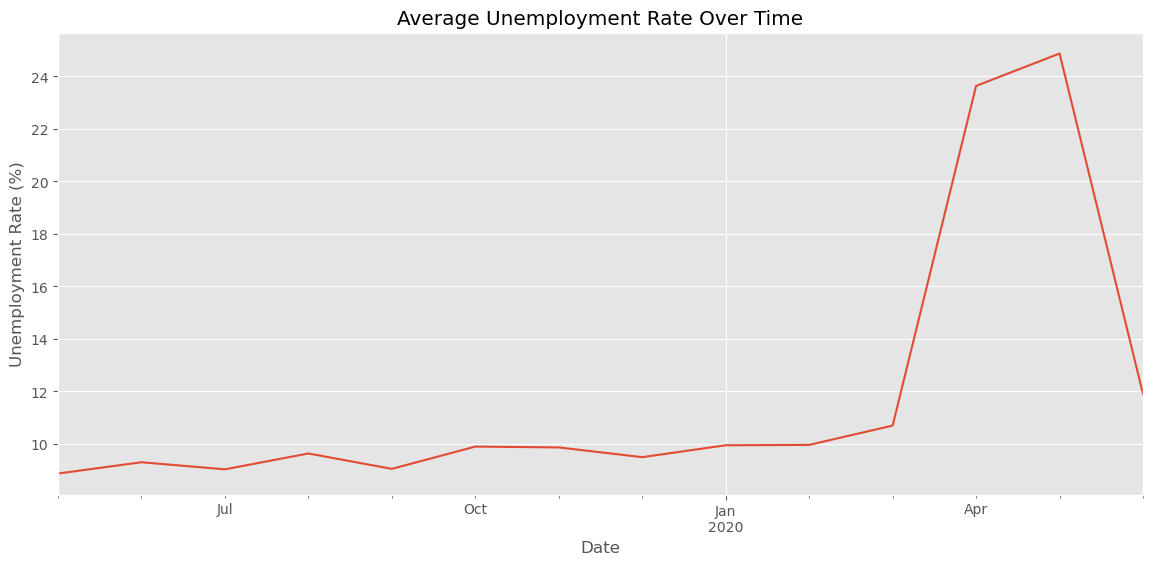

In [19]:
monthly_trend = df.groupby('Date')['Estimated Unemployment Rate (%)'].mean()

plt.figure(figsize=(14,6))
monthly_trend.plot()

plt.title("Average Unemployment Rate Over Time")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")
plt.show()

## Top 10 States with Highest Unemployment

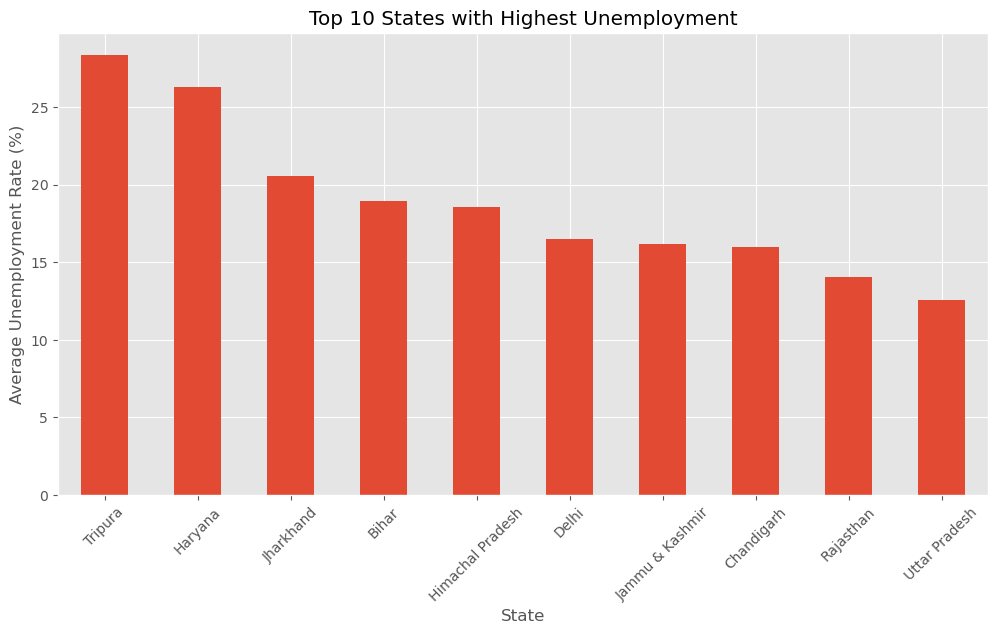

In [20]:
state_unemployment = (
    df.groupby('Region')['Estimated Unemployment Rate (%)']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12,6))
state_unemployment.head(10).plot(kind='bar')

plt.title("Top 10 States with Highest Unemployment")
plt.xlabel("State")
plt.ylabel("Average Unemployment Rate (%)")
plt.xticks(rotation=45)
plt.show()

## Top 10 States with Lowest Unemployment

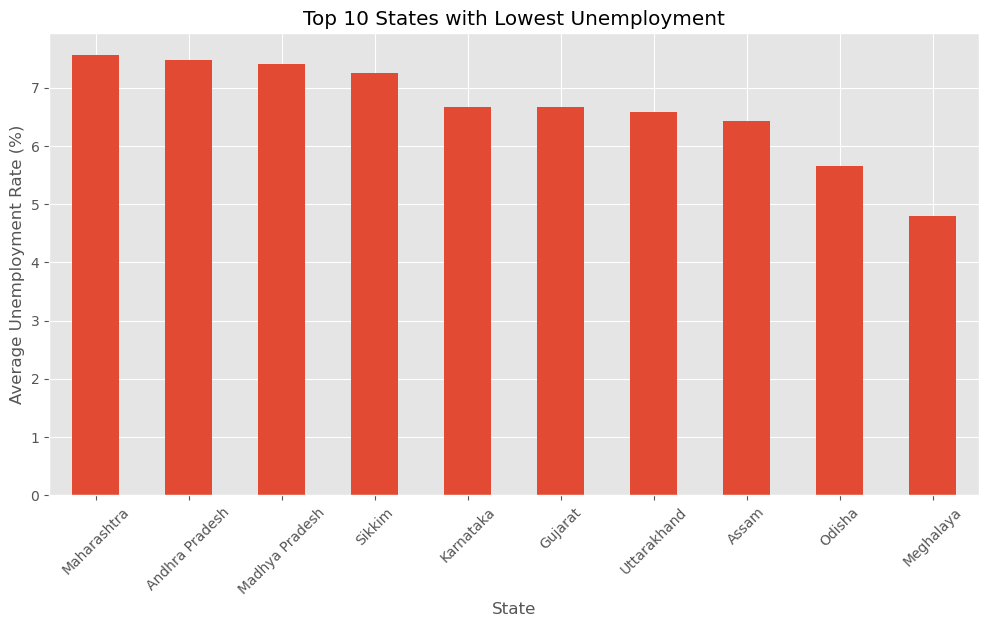

In [21]:
plt.figure(figsize=(12,6))
state_unemployment.tail(10).plot(kind='bar')

plt.title("Top 10 States with Lowest Unemployment")
plt.xlabel("State")
plt.ylabel("Average Unemployment Rate (%)")
plt.xticks(rotation=45)
plt.show()

# Covid-19 Impact Analysis

## Before vs During Covid

In [22]:
before_covid = df[df['Date'] < '2020-03-01']
during_covid = df[df['Date'] >= '2020-03-01']

print("Average Before Covid:", round(before_covid['Estimated Unemployment Rate (%)'].mean(), 2))
print("Average During Covid:", round(during_covid['Estimated Unemployment Rate (%)'].mean(), 2))

Average Before Covid: 9.51
Average During Covid: 17.77


## Covid Impact Trend

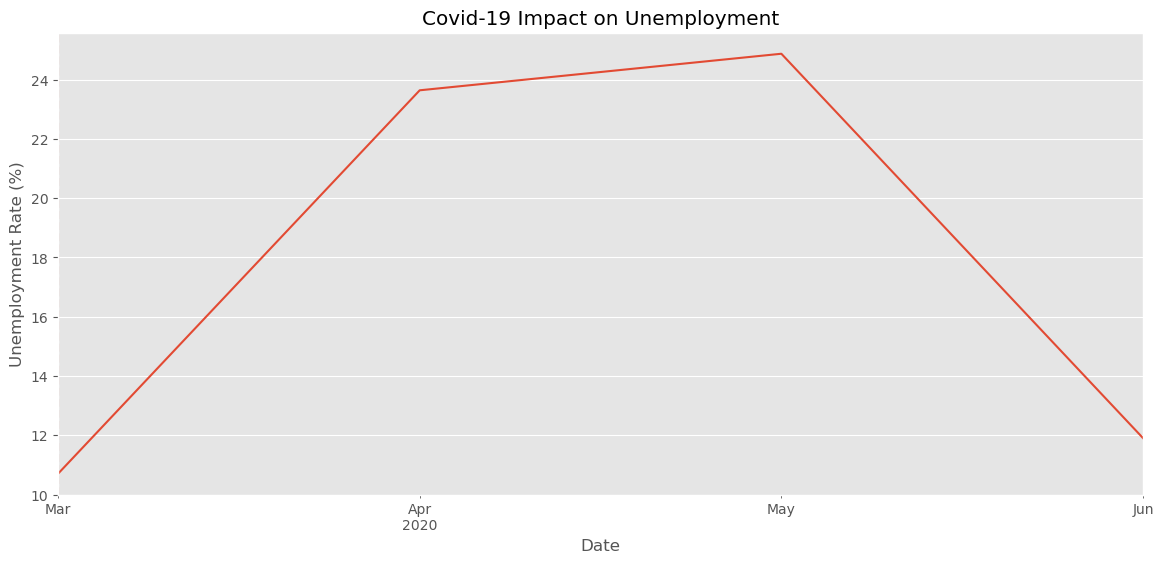

In [23]:
covid_trend = (
    during_covid.groupby('Date')['Estimated Unemployment Rate (%)']
    .mean()
)

plt.figure(figsize=(14,6))
covid_trend.plot()

plt.axvline(pd.to_datetime('2020-03-01'), linestyle='--')
plt.title("Covid-19 Impact on Unemployment")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")
plt.show()

## Urban vs Rural Unemployment

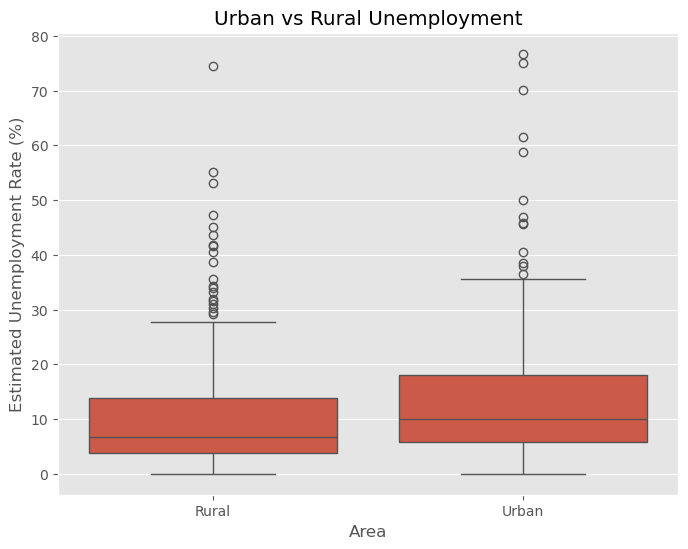

In [24]:
plt.figure(figsize=(8,6))
sns.boxplot(x='Area', y='Estimated Unemployment Rate (%)', data=df)
plt.title("Urban vs Rural Unemployment")
plt.show()

## Labour Participation Rate Analysis

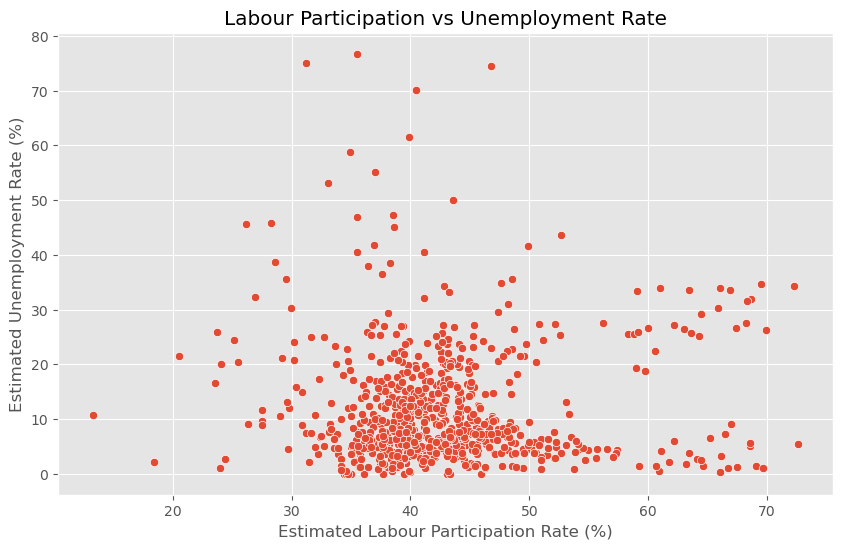

In [25]:
plt.figure(figsize=(10,6))
sns.scatterplot(
    x='Estimated Labour Participation Rate (%)',
    y='Estimated Unemployment Rate (%)',
    data=df
)

plt.title("Labour Participation vs Unemployment Rate")
plt.show()

## Correlation Heatmap

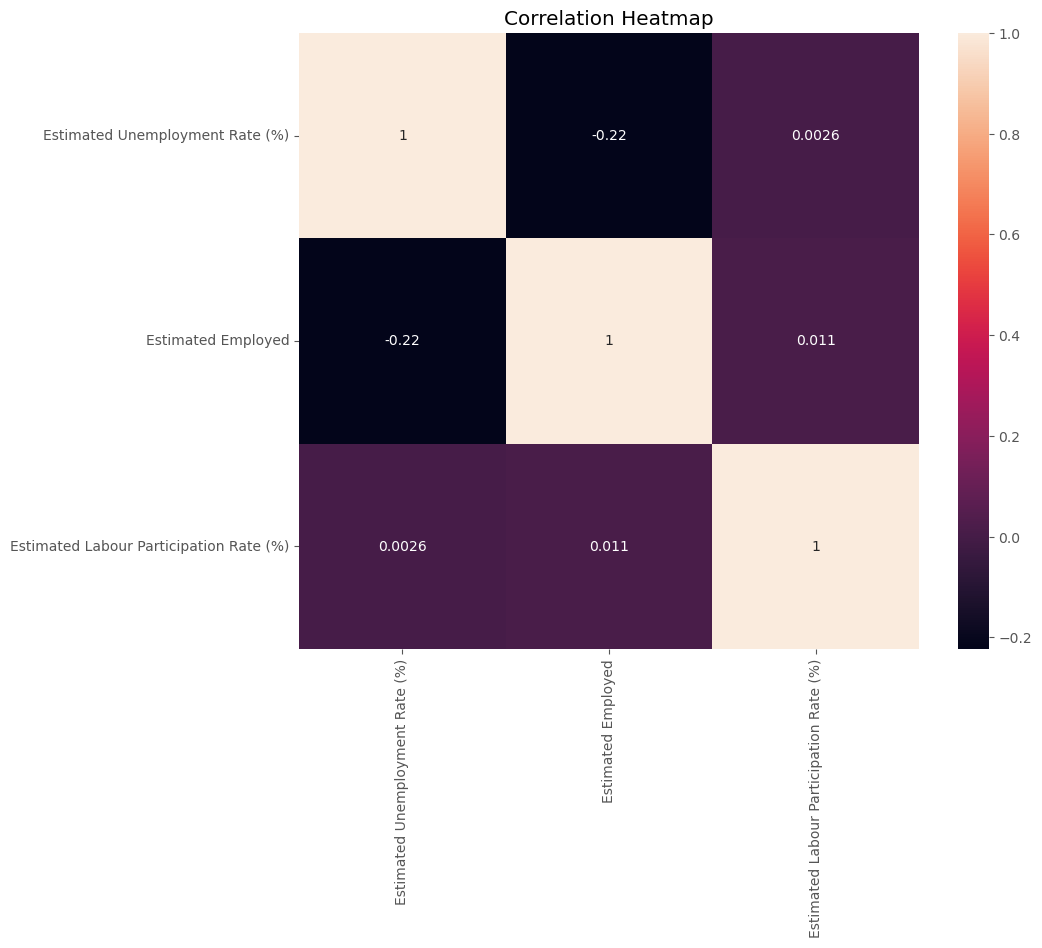

In [26]:
numeric_df = df.select_dtypes(include=['number'])

plt.figure(figsize=(10,8))
sns.heatmap(numeric_df.corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()

# Key Insights

In [27]:
print("Highest Unemployment Rate:", df['Estimated Unemployment Rate (%)'].max())
print("Lowest Unemployment Rate:", df['Estimated Unemployment Rate (%)'].min())
print("Average Unemployment Rate:", round(df['Estimated Unemployment Rate (%)'].mean(), 2))

Highest Unemployment Rate: 76.74
Lowest Unemployment Rate: 0.0
Average Unemployment Rate: 11.79


# Conclusion

1. The unemployment rate increased significantly during the Covid-19 pandemic.
2. April and May 2020 showed the highest unemployment levels due to lockdown restrictions.
3. Certain states experienced consistently higher unemployment compared to others.
4. Urban and rural areas displayed different unemployment patterns.
5. The analysis highlights the importance of employment support programs and economic recovery policies during national crises.
6. Data visualization helped identify major unemployment trends and the overall impact of Covid-19 on the Indian labour market.